# Sample-Specific Variance in Differential Analysis

This tutorial demonstrates how to account for biological variability across samples in differential analysis. This is crucial when analyzing data from multiple biological replicates.

## Why Sample Variance Matters

When comparing conditions (e.g., treated vs. control), we typically have multiple biological replicates per condition. Biological variation **between samples** within the same condition is often larger than technical variation, and ignoring it can lead to:

- Inflated statistical significance
- High false positive rates
- Poor reproducibility across studies

Kompot's sample variance estimation:

✓ Builds separate estimators for each sample  
✓ Computes sample-to-sample covariance  
✓ Adjusts significance based on inter-sample variability  
✓ Produces more conservative and reproducible results  

## Dataset

We'll use bone marrow data from young and old mice, with 3 biological replicates per age group.

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import palantir
import pandas as pd
import scanpy as sc

import kompot

plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["image.cmap"] = "Spectral_r"

In [2]:
DATA_PATH = "../data/murine_bone_marrow_aging.h5ad"
SAMPLE_COLUMN = "Replicate"        # Sample/replicate identifiers
GROUPING_COLUMN = "Age"
CONDITIONS = ["Young", "Old"]
CELL_TYPE_COLUMN = "highres_celltype"
DIMENSIONALITY_REDUCTION = "DM_EigenVectors"
LAYER_FOR_EXPRESSION = "logged_counts"

## Load Data

In [3]:
adata = ad.read_h5ad(DATA_PATH)
palantir.utils.run_diffusion_maps(adata, pca_key="X_pca_harmony", n_components=40)
adata

/fh/fast/setty_m/user/dotto/kompot/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "/fh/fast/setty_m/user/dotto/kompot/.venv/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


AnnData object with n_obs × n_vars = 8090 × 16285
    obs: 'Compartment', 'Replicate', 'Age', 'Sample', 'Info', 'batch', 'doublet_score', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'leiden', 'phenograph', 'highres_celltype', 'midres_celltype'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Age_colors', 'Compartment_colors', 'DMEigenValues', 'Info_colors', 'README', 'Replicate_colors', 'Sample_colors', 'batch_colors', 'draw_graph', 'highres_celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'midres_celltype_colors', 'neighbors', 'pca', 'phase_colors', 'umap', 'DM_EigenValues'
    obsm: 'AbCapture', 'DM_EigenVectors', 'HTO', 'X_draw_graph_fa', 'X_pca', 'X_pca_harmony', 'X_

### Examine Sample Structure

In [4]:
# Check sample distribution
sample_counts = adata.obs.groupby([GROUPING_COLUMN, SAMPLE_COLUMN]).size().unstack(fill_value=0)
print("Cells per sample:\n", sample_counts)

Cells per sample:
 Replicate     1     2     3
Age                        
Mid        1035  1022     0
Old        1057  1019  1040
Young       944  1007   966


/tmp/ipykernel_32012/1340399861.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_counts = adata.obs.groupby([GROUPING_COLUMN, SAMPLE_COLUMN]).size().unstack(fill_value=0)


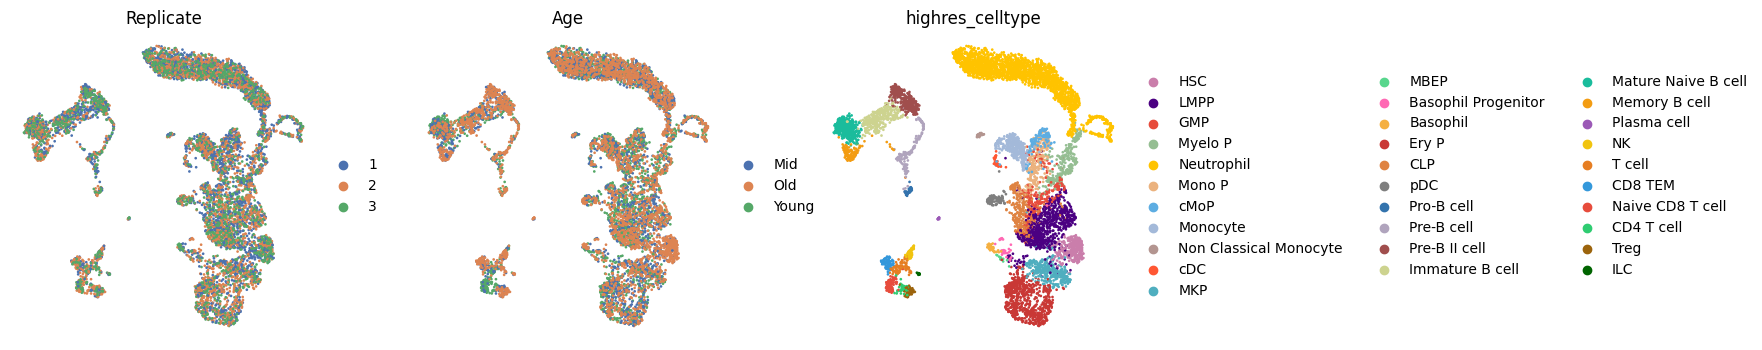

In [5]:
sc.pl.umap(adata, color=[SAMPLE_COLUMN, GROUPING_COLUMN, CELL_TYPE_COLUMN], wspace=.2, frameon=False)

## Standard Analysis (Without Sample Variance)

First, we'll run analyses **without** accounting for sample variance. This serves as a baseline for comparison.

### Differential Abundance

In [6]:
da_standard = kompot.da(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    obsm_key=DIMENSIONALITY_REDUCTION,
)

[2026-03-26 05:57:36,779] [INFO    ] Condition 1 (Young): 2,917 cells
[2026-03-26 05:57:36,781] [INFO    ] Condition 2 (Old): 3,116 cells
[2026-03-26 05:57:36,789] [INFO    ] Fitting density estimator for condition 1...
[2026-03-26 05:58:03,480] [INFO    ] Fitting density estimator for condition 2...
[2026-03-26 05:58:22,431] [INFO    ] This run will have `run_id=0`.


### Differential Expression

In [7]:
de_standard = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
)

[2026-03-26 05:58:22,462] [INFO    ] Condition 1 (Young): 2,917 cells
[2026-03-26 05:58:22,463] [INFO    ] Condition 2 (Old): 3,116 cells
[2026-03-26 05:58:26,402] [INFO    ] Fitting expression estimator for condition 1...
[2026-03-26 05:58:33,174] [INFO    ] Fitting expression estimator for condition 2...


Predicting expression:   1%|1         | 1/81 [00:00<?, ?it/s]

Predicting expression:   1%|1         | 1/81 [00:00<?, ?it/s]

Computing GP covariance (diag):   1%|1         | 1/81 [00:00<?, ?it/s]

Computing GP covariance (diag):   1%|1         | 1/81 [00:00<?, ?it/s]

Computing Cholesky Mahalanobis distances:   1%|          | 1/183 [00:00<?, ?it/s]

[2026-03-26 06:01:20,302] [INFO    ] FDR analysis complete: 192/16285 genes significantly DE at FDR < 0.05
[2026-03-26 06:01:20,304] [INFO    ] Mahalanobis distance threshold for FDR < 0.05: 27.3487
[2026-03-26 06:01:24,716] [INFO    ] This run will have `run_id=0`.


## Analysis With Sample Variance

Now we'll repeat the analyses while accounting for sample variance by specifying the `sample_col` parameter.

### Differential Abundance

When accounting for sample variance, you may want to relax significance thresholds slightly, as the test becomes more conservative:

In [8]:
da_sample_var = kompot.da(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,  # Enable sample variance
    threshold=kompot.DAThresholdSettings(ptp_threshold=0.1),  # Relaxed from default 0.05
)

[2026-03-26 06:01:24,924] [INFO    ] Results with result_key='kompot_da' already exist in the dataset. Previous run was at 2026-03-26T05:58:22.404716 comparing Young to Old. Fields that will be overwritten: obs.kompot_da_Young_to_Old_lfc, obs.kompot_da_Young_log_density, obs.kompot_da_Old_log_density. Note: Only fields NOT affected by sample variance (like lfc, log_density) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2026-03-26 06:01:24,929] [INFO    ] Condition 1 (Young): 2,917 cells
[2026-03-26 06:01:24,930] [INFO    ] Condition 2 (Old): 3,116 cells
[2026-03-26 06:01:24,937] [INFO    ] Using sample column 'Replicate' for sample variance estimation
[2026-03-26 06:01:24,939] [INFO    ] Found 3 unique sa

### Differential Expression

For DE with sample variance, memory requirements increase because Kompot computes gene-specific covariance matrices. We'll use several strategies to manage this:

1. **Limit to top genes**: Analyze only the most significant genes from the standard analysis
2. **Use disk storage**: Store large covariance matrices on disk instead of in memory
3. **Disable null genes**: Skip FDR computation (set `null_genes=0`) to avoid computing sample covariances for null genes

#### Resource Planning

Before running, estimate resource requirements:

In [9]:
# Select top 200 genes
topn = 200
top_genes = adata.var.sort_values(
    "kompot_de_Young_to_Old_mahalanobis", ascending=False
).head(topn).index

# Check resource requirements with dry_run
plan = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,
    genes=top_genes,
    gp=kompot.GPSettings(batch_size=0),
    storage=kompot.StorageSettings(store_arrays_on_disk=True),
    fdr=kompot.FDRSettings(null_genes=0),  # Skip FDR to save memory
    dry_run=True,
)

RESOURCE USAGE PLAN

System Resources:
  Memory: 308.22 GB available (of 754.59 GB total)
  Disk:   377.28 GB available at /tmp

Total Requirements:
  Memory: 1.60 GB (1% of available)
  Disk:   74.51 GB (20% of available)

Memory Allocations:
  • Mellon precision matrix L (condition 1, 2,917/3,116 cells) (np.int64(2917), np.int64(2917)): 64.92 MB
  • Mellon precision matrix L (condition 2, 2,917/3,116 cells) (np.int64(3116), np.int64(3116)): 74.08 MB
  • Imputed expression (condition 1) (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_imputed']
  • Imputed expression (condition 2) (8090, 200): 12.34 MB → adata.layers['kompot_de_Old_imputed']
  • Fold change (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_to_Old_fold_change']
  • Standard deviation (condition 1) (8090, 200): 12.34 MB → adata.layers['kompot_de_Young_std']
  • Standard deviation (condition 2) (8090, 200): 12.34 MB → adata.layers['kompot_de_Old_std']
  • Temporary matrices during predictions (batch_size=0) (809

The dry run shows:
- Memory requirements for sample covariance computation
- Disk space needed for storage
- Which fields will be overwritten
- Previous run details

If resources are sufficient, proceed with the analysis:

In [10]:
de_sample_var = kompot.de(
    adata,
    groupby=GROUPING_COLUMN,
    condition1=CONDITIONS[0],
    condition2=CONDITIONS[1],
    layer=LAYER_FOR_EXPRESSION,
    obsm_key=DIMENSIONALITY_REDUCTION,
    sample_col=SAMPLE_COLUMN,
    genes=top_genes,
    storage=kompot.StorageSettings(store_arrays_on_disk=True),
    fdr=kompot.FDRSettings(null_genes=0),
)

[2026-03-26 06:02:29,791] [INFO    ] Differential expression results with result_key='kompot_de' already exist in the dataset. Previous run was at 2026-03-26T06:01:24.674200 comparing Young to Old. Fields that will be overwritten: var.kompot_de_Young_to_Old_mean_lfc, layers.kompot_de_Young_imputed, layers.kompot_de_Old_imputed, layers.kompot_de_Young_to_Old_fold_change. Note: Only fields NOT affected by sample variance (like mean_log_fold_change, imputed data, fold_change) will be overwritten since they don't use the sample variance suffix. These results will likely be identical if other parameters haven't changed. This is a partial rerun with sample variance added to a previous analysis with matching parameters. Set overwrite=False to prevent overwriting or overwrite=True to silence this message.
[2026-03-26 06:02:29,795] [INFO    ] Condition 1 (Young): 2,917 cells
[2026-03-26 06:02:29,796] [INFO    ] Condition 2 (Old): 3,116 cells
[2026-03-26 06:02:30,403] [INFO    ] Using sample col

Predicting expression:   1%|1         | 1/81 [00:00<?, ?it/s]

Predicting expression:   1%|1         | 1/81 [00:00<?, ?it/s]

Computing GP covariance (diag):   1%|1         | 1/81 [00:00<?, ?it/s]

Computing sample variance:   1%|1         | 1/81 [00:00<?, ?it/s]

...

Computing covariance:   0%|          | 0/200 [00:00<?, ?it/s]

Processing gene-specific covariance matrices:   0%|          | 0/200 [00:00<?, ?it/s]

[2026-03-26 06:14:40,089] [INFO    ] Computing Mahalanobis distances using gene-specific covariance matrices


Computing gene-specific Mahalanobis distances:   0%|          | 0/200 [00:00<?, ?it/s]

[2026-03-26 06:25:02,604] [INFO    ] Updating 200 genes (1.2% of total) in existing sparse layers: kompot_de_Young_std, kompot_de_Old_std. Temporarily converting CSR->LIL->CSR to avoid slow per-gene modifications.
[2026-03-26 06:25:04,258] [INFO    ] This run will have `run_id=1`.
[2026-03-26 06:25:07,168] [INFO    ] Removed temporary storage directory /tmp/kompot_arrays_b5a02879_cco5xnqo
[2026-03-26 06:25:09,621] [INFO    ] Removed temporary storage directory /tmp/kompot_arrays_8a363704_l16k6lr9


## Comparing Results

### Differential Abundance

Results with sample variance include a `_sample_var` suffix to distinguish them from standard results.

Compare z-scores with and without sample variance:

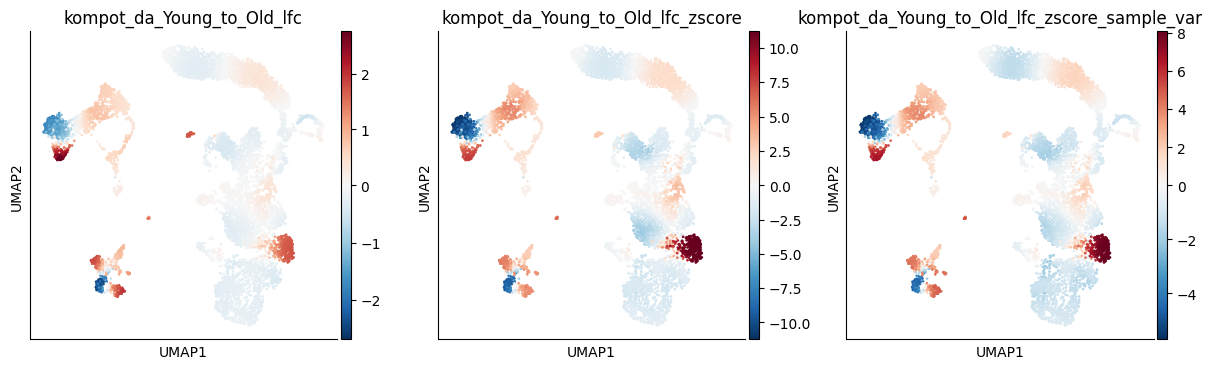

In [11]:
sc.pl.embedding(
    adata, "umap",
    color=[
        "kompot_da_Young_to_Old_lfc",
        "kompot_da_Young_to_Old_lfc_zscore",
        "kompot_da_Young_to_Old_lfc_zscore_sample_var",
    ],
    color_map="RdBu_r",
    vcenter=0,
    ncols=3,
)

Notice:
- Log fold changes (left) are identical - sample variance only affects significance
- Z-scores (middle and right) differ - sample variance produces more conservative estimates

### Volcano Plots

Compare volcano plots from both analyses:

[2026-03-26 06:25:10,319] [INFO    ] Found DA run info for run_id=0
[2026-03-26 06:25:10,322] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2026-03-26 06:25:10,323] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp' from run info
[2026-03-26 06:25:10,325] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2026-03-26 06:25:10,327] [WARNING ] Field 'kompot_da_Young_to_Old_neg_log10_lfc_ptp' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2026-03-26 06:25:10,327] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp'}
[2026-03-26 06:25:10,328] [WARNING ] Field inference completed with 2 warnings
[2026-03-26 06:25:10,330] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.05


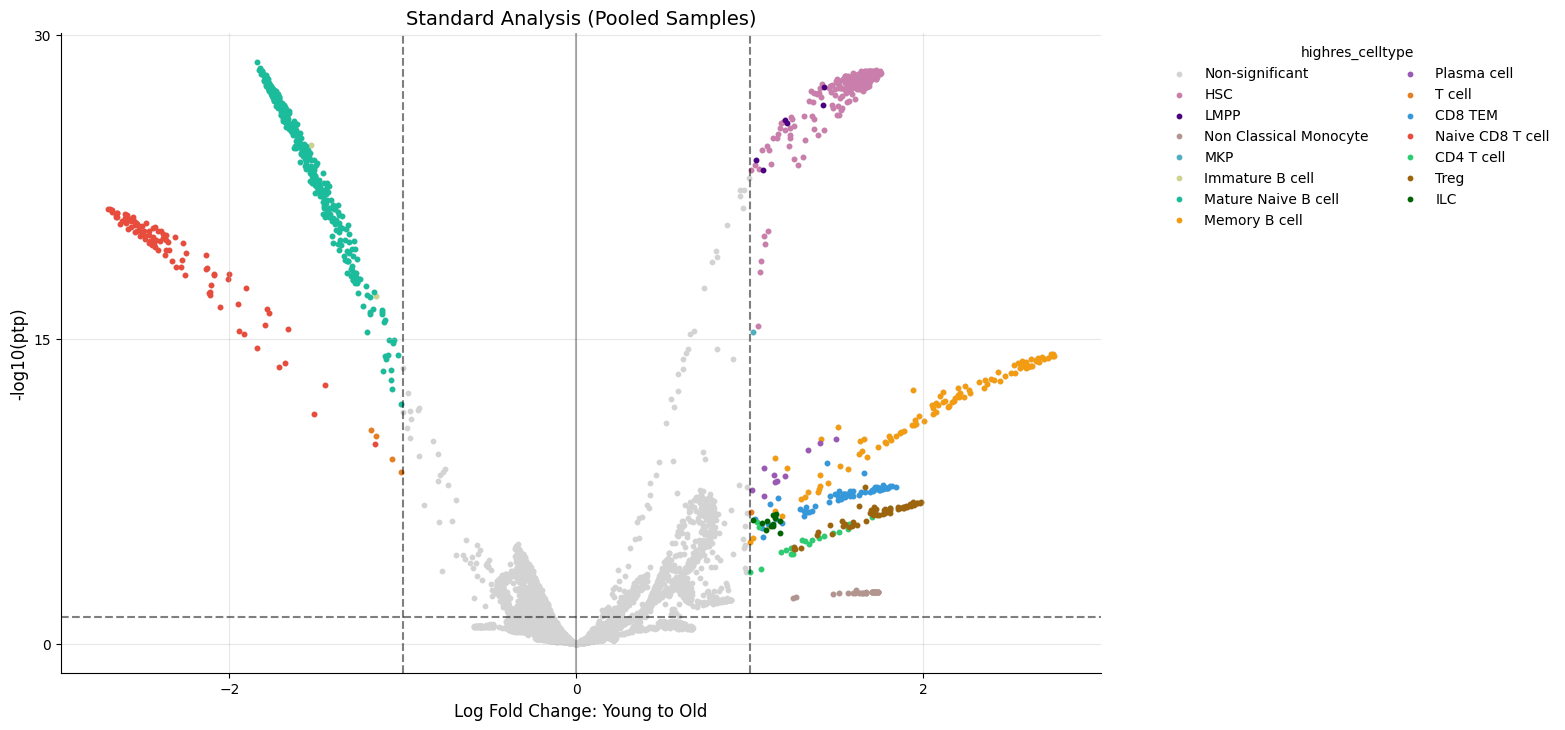

In [12]:
# Standard analysis (run_id=0)
kompot.plot.volcano_da(
    adata, 
    color=CELL_TYPE_COLUMN, 
    run_id=0,
    title="Standard Analysis (Pooled Samples)",
)

[2026-03-26 06:25:10,889] [INFO    ] Found DA run info for run_id=1
[2026-03-26 06:25:10,891] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2026-03-26 06:25:10,892] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var' from run info
[2026-03-26 06:25:10,894] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2026-03-26 06:25:10,895] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var'}
[2026-03-26 06:25:10,896] [WARNING ] Field inference completed with 1 warnings
[2026-03-26 06:25:10,898] [INFO    ] Using inferred thresholds - lfc_threshold: 1.0, ptp_threshold: 0.1


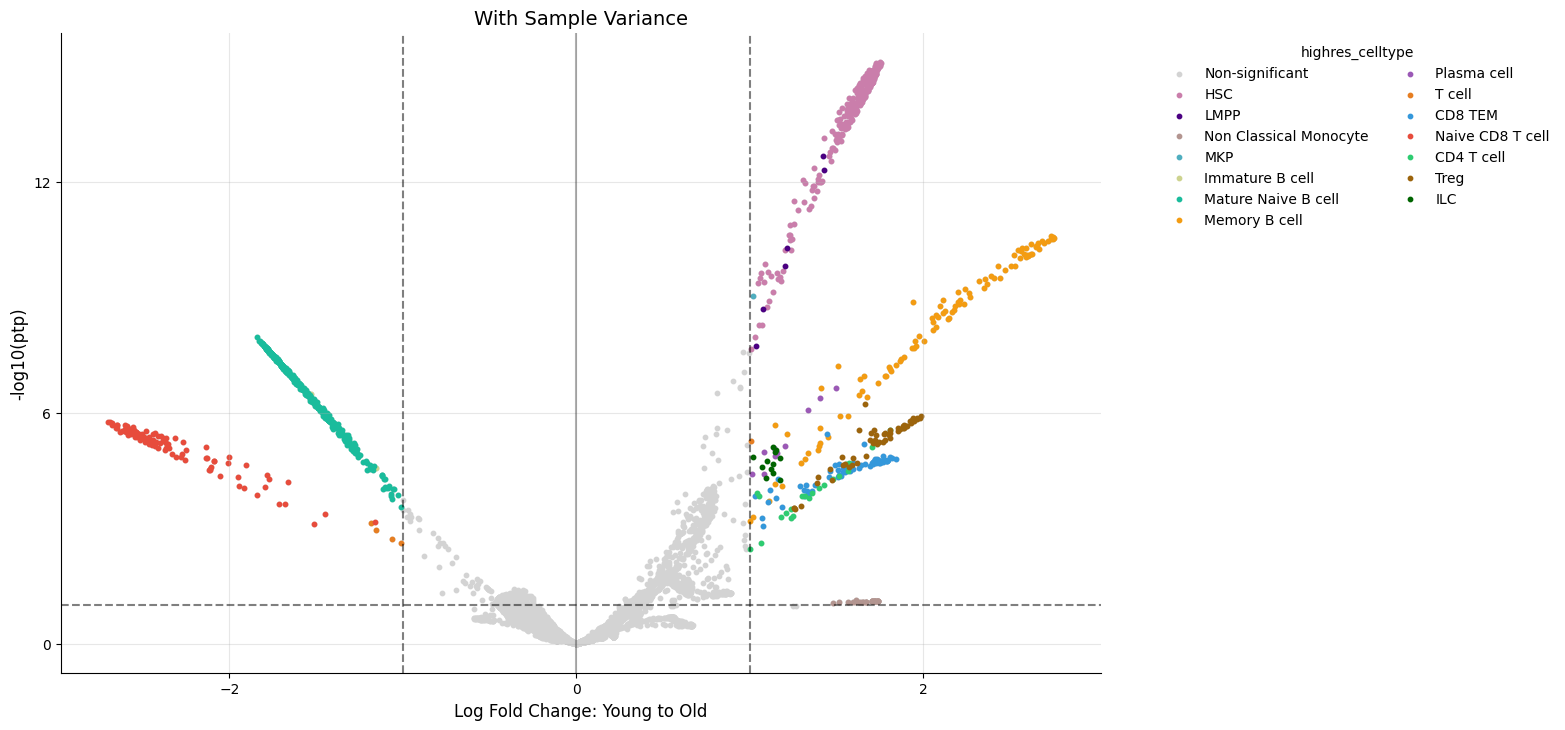

In [13]:
# With sample variance (run_id=1)
kompot.plot.volcano_da(
    adata, 
    color=CELL_TYPE_COLUMN, 
    run_id=1,
    title="With Sample Variance",
)

Note that thresholds such as `ptp_threshold` and `lfc_threshold` can be adjusted, and if `update_direction=True` is passed, then the cell-wise classification in `adata.obs["kompot_da_Young_to_Old_lfc_direction_sample_var"]` is updated accordingly.

[2026-03-26 06:25:11,433] [INFO    ] Found DA run info for run_id=1
[2026-03-26 06:25:11,434] [INFO    ] Found lfc_key='kompot_da_Young_to_Old_lfc' from run info
[2026-03-26 06:25:11,435] [INFO    ] Found ptp_key='kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var' from run info
[2026-03-26 06:25:11,436] [WARNING ] Field 'kompot_da_Young_to_Old_lfc' has been written by 2 different runs, indicating potential overwrites
[2026-03-26 06:25:11,438] [INFO    ] Successfully inferred fields: {'lfc_key': 'kompot_da_Young_to_Old_lfc', 'ptp_key': 'kompot_da_Young_to_Old_neg_log10_lfc_ptp_sample_var'}
[2026-03-26 06:25:11,438] [WARNING ] Field inference completed with 1 warnings
[2026-03-26 06:25:11,439] [INFO    ] Updating direction column with new thresholds before plotting
[2026-03-26 06:25:11,440] [INFO    ] Found DA run info for run_id=1
[2026-03-26 06:25:11,440] [INFO    ] Found direction_key='kompot_da_Young_to_Old_lfc_direction_sample_var' from run info
[2026-03-26 06:25:11,441] [INFO    

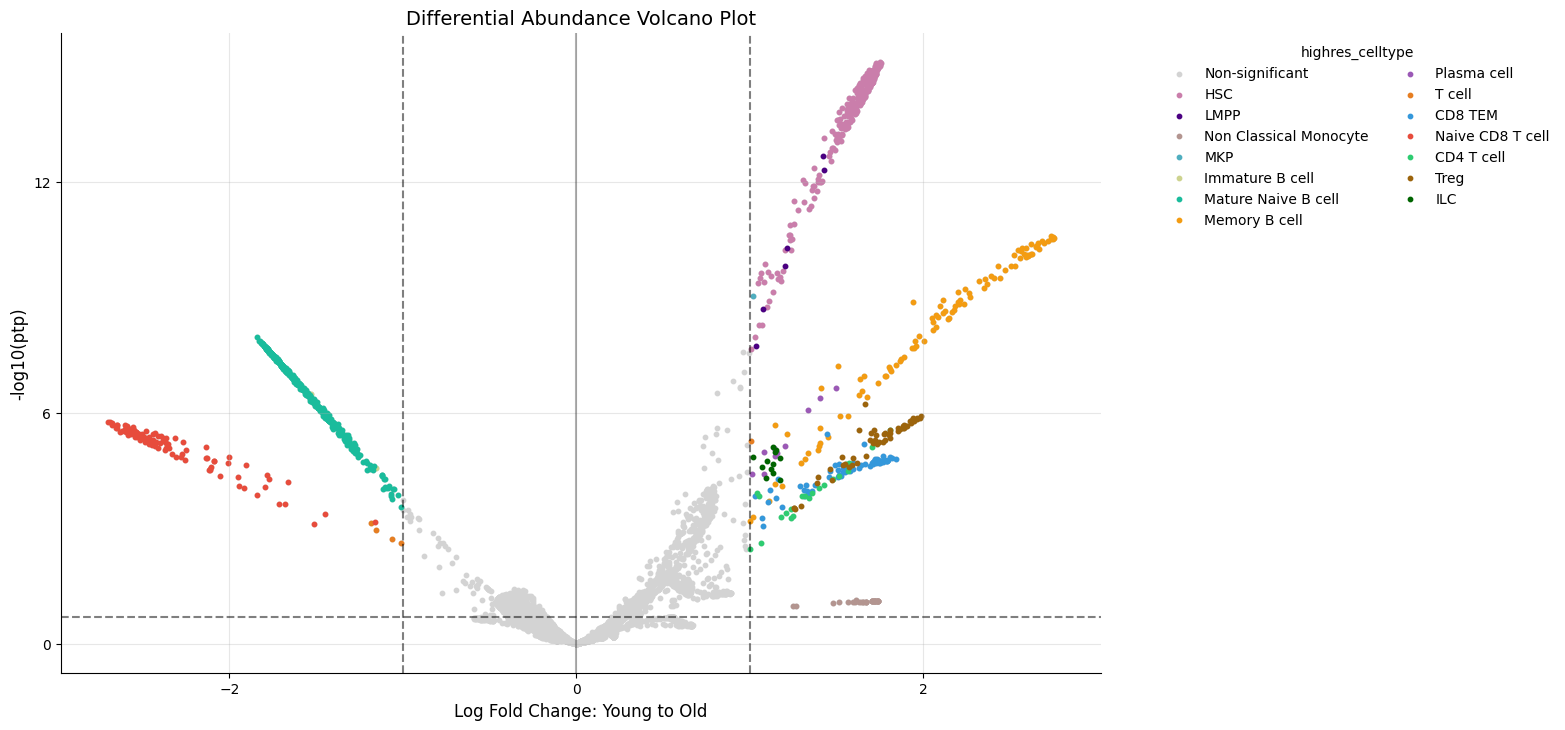

In [14]:
kompot.plot.volcano_da(adata, color=CELL_TYPE_COLUMN, run_id=1, ptp_threshold=0.2, update_direction=True)

**Key Observations:**

- Posterior tail probabilities (y-axis) are generally lower with sample variance
- Fewer cells pass significance thresholds
- Effect sizes (x-axis) remain unchanged
- Cell type patterns are preserved but with adjusted confidence

### Differential Expression

Compare Mahalanobis distances with and without sample variance:

In [15]:
# Top genes by standard analysis
comparison_df = adata.var.loc[top_genes, :][
    [
        "kompot_de_Young_to_Old_mean_lfc",
        "kompot_de_Young_to_Old_mahalanobis",
        "kompot_de_Young_to_Old_mahalanobis_sample_var",
    ]
].sort_values("kompot_de_Young_to_Old_mahalanobis", ascending=False)

comparison_df.head(20)

,kompot_de_Young_to_Old_mean_lfc,kompot_de_Young_to_Old_mahalanobis,kompot_de_Young_to_Old_mahalanobis_sample_var
H2-Q7,1.235127,71.525389,45.080033
Cd74,0.352017,60.045402,49.605440
H2-Aa,0.473619,59.386737,38.492532
H2-Ab1,0.510985,57.821672,33.767935
Igkc,0.053961,53.632533,38.989996
H2-Eb1,0.411615,53.420015,31.736385
AW112010,0.791454,53.397625,28.092953
S100a9,-0.170284,48.791349,46.520761
Ifitm3,0.367547,47.608968,40.394761
S100a8,-0.165096,47.399107,45.514942


Notice that some genes show substantially lower significance when accounting for sample variance, indicating high variability across replicates.

[2026-03-26 06:25:12,061] [INFO    ] Found DE run info for run_id=0
[2026-03-26 06:25:12,063] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-26 06:25:12,064] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis' from run info
[2026-03-26 06:25:12,065] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites
[2026-03-26 06:25:12,066] [WARNING ] Field 'kompot_de_Young_to_Old_mahalanobis' was last written by run 0, but current context expects run 1. The field may have been overwritten.
[2026-03-26 06:25:12,067] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis'}
[2026-03-26 06:25:12,068] [WARNING ] Field inference completed with 2 warnings
[2026-03-26 06:25:12,069] [INFO    ] Using DE run 0: comparing Young to Old
[2026-03-26 06:25:12,083] [INFO    ] Using data columns from 

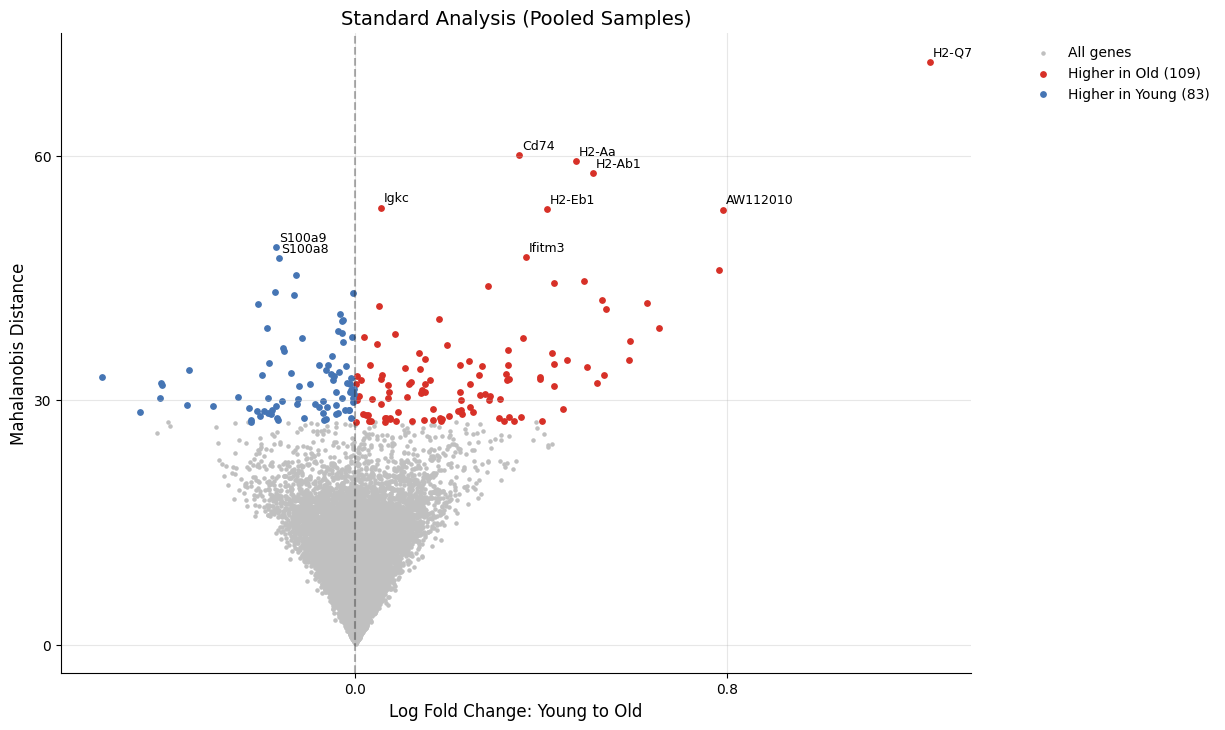

In [16]:
# Volcano plot: Standard analysis
kompot.plot.volcano_de(
    adata,
    run_id=0,
    title="Standard Analysis (Pooled Samples)",
)

[2026-03-26 06:25:12,395] [INFO    ] Found DE run info for run_id=1
[2026-03-26 06:25:12,396] [INFO    ] Found mean_lfc_key='kompot_de_Young_to_Old_mean_lfc' from run info
[2026-03-26 06:25:12,397] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run info
[2026-03-26 06:25:12,398] [WARNING ] Field 'kompot_de_Young_to_Old_mean_lfc' has been written by 2 different runs, indicating potential overwrites
[2026-03-26 06:25:12,399] [INFO    ] Successfully inferred fields: {'mean_lfc_key': 'kompot_de_Young_to_Old_mean_lfc', 'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis_sample_var'}
[2026-03-26 06:25:12,400] [WARNING ] Field inference completed with 1 warnings
[2026-03-26 06:25:12,401] [INFO    ] Using DE run 1: comparing Young to Old
[2026-03-26 06:25:12,417] [INFO    ] Using data columns from var - lfc: 'kompot_de_Young_to_Old_mean_lfc', score: 'kompot_de_Young_to_Old_mahalanobis_sample_var'
[2026-03-26 06:25:12,421] [INFO    ] Highlighting top 50

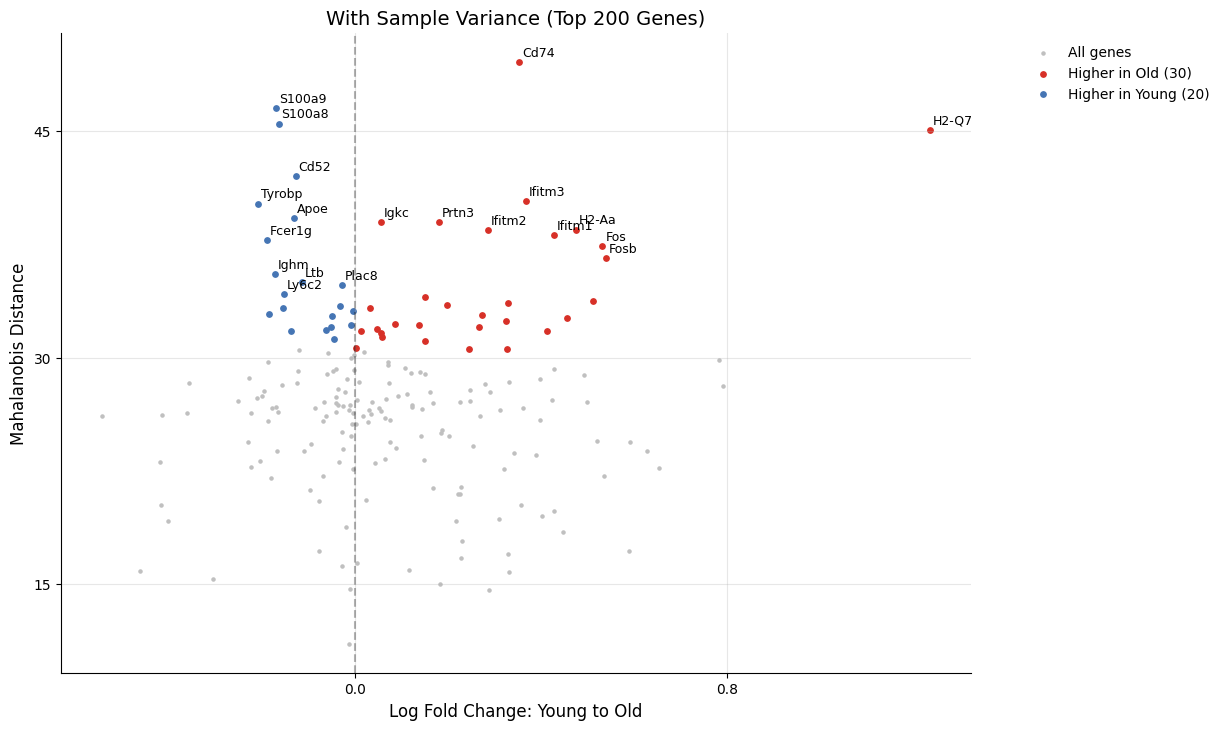

In [17]:
# Volcano plot: With sample variance
kompot.plot.volcano_de(
    adata,
    run_id=1,
    n_top_genes=50,  # No FDR threshold available (null_genes=0)
    gene_labels=20,
    title="With Sample Variance (Top 200 Genes)",
)

### Heatmaps

Visualize how ranking changes with sample variance:

[2026-03-26 06:25:12,726] [INFO    ] Found DE run info for run_id=1
[2026-03-26 06:25:12,727] [INFO    ] Found mahalanobis_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run info
[2026-03-26 06:25:12,729] [INFO    ] Successfully inferred fields: {'mahalanobis_key': 'kompot_de_Young_to_Old_mahalanobis_sample_var'}
[2026-03-26 06:25:12,730] [INFO    ] Using DE run 1 for heatmap.
[2026-03-26 06:25:12,731] [INFO    ] Inferred score_key='kompot_de_Young_to_Old_mahalanobis_sample_var' from run information
[2026-03-26 06:25:12,735] [INFO    ] Inferred condition_column='Age' from run information
[2026-03-26 06:25:12,736] [INFO    ] Inferred condition1='Young' from run information
[2026-03-26 06:25:12,736] [INFO    ] Inferred condition2='Old' from run information
[2026-03-26 06:25:12,737] [INFO    ] Inferred layer='logged_counts' from run information
[2026-03-26 06:25:12,737] [INFO    ] Creating split heatmap with 20 genes/features
[2026-03-26 06:25:12,739] [INFO    ] Using expression

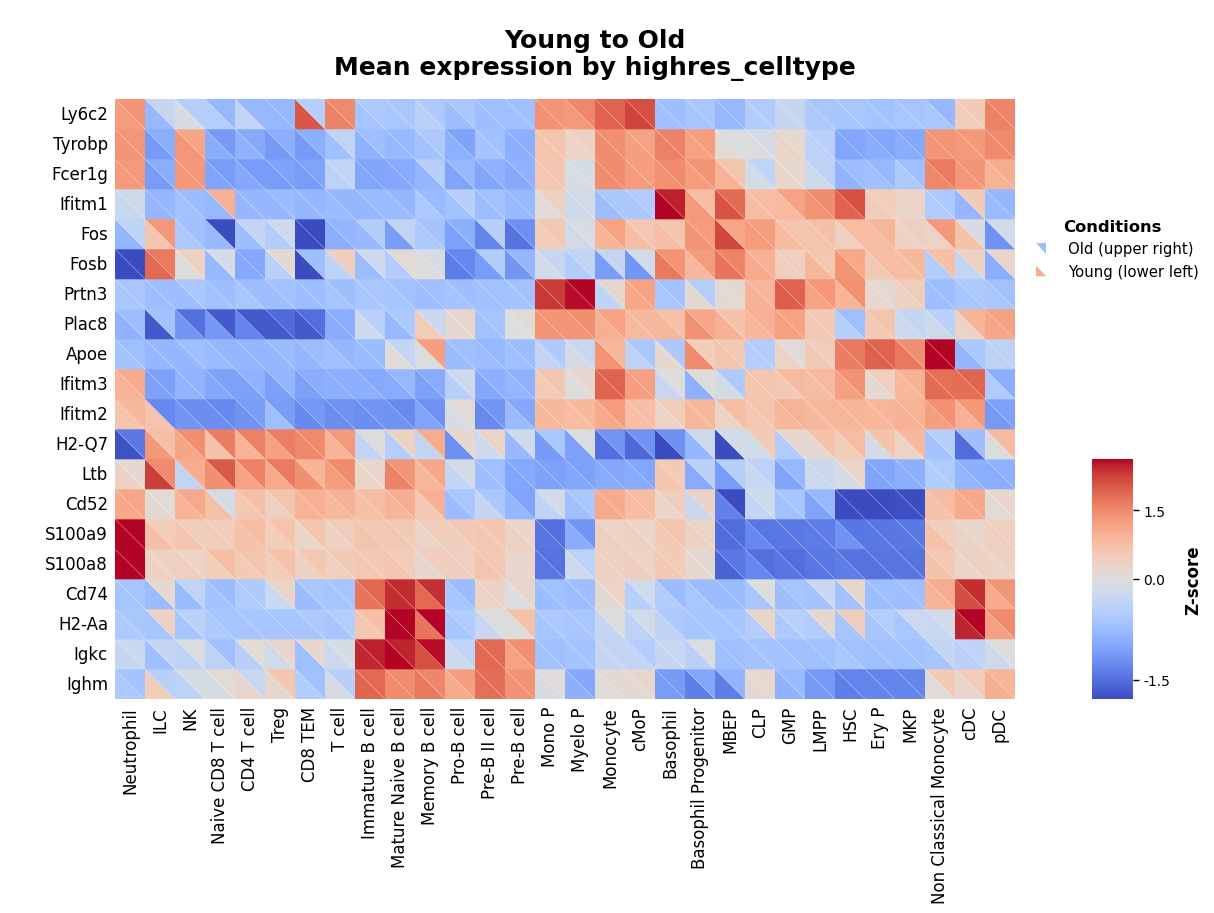

In [18]:
kompot.plot.heatmap(
    adata,
    n_top_genes=20,
    groupby=CELL_TYPE_COLUMN,
    exclude_groups="Plasma cell",
    run_id=1,  # Use sample variance ranking
    vmin="p1",
    vmax="p99",
)

## Understanding Sample-to-Sample Variability

To illustrate why sample variance matters, let's examine genes with high inter-sample variability:

In [19]:
# Genes with largest decrease in significance
comparison_df["decrease"] = (
    comparison_df["kompot_de_Young_to_Old_mahalanobis"] - 
    comparison_df["kompot_de_Young_to_Old_mahalanobis_sample_var"]
)

variable_genes = comparison_df.nlargest(20, "decrease").index
print("Genes with highest sample-to-sample variability:")
print(variable_genes.tolist())

Genes with highest sample-to-sample variability:
['H2-Q7', 'AW112010', 'H2-Ab1', 'H2-Eb1', 'H2-Aa', 'Gm47283', 'Ifi27', 'Bcl11b', 'Slc7a11', 'Gimap4', 'Trac', 'H2-Q6', 'Cirbp', 'Ccl5', 'Trbc2', 'Aldh1a1', 'Cxcl2', 'Cd3e', 'Cd3g', 'Igkc']


Compare expression between individual replicates:

[2026-03-26 06:25:14,191] [INFO    ] Inferred layer='logged_counts' from run information
[2026-03-26 06:25:14,193] [INFO    ] Creating split heatmap with 20 genes/features
[2026-03-26 06:25:14,194] [INFO    ] Using display names: 'Replicate 1' for condition1, 'Replicate 3' for condition2
[2026-03-26 06:25:14,195] [INFO    ] Using expression data from layer: 'logged_counts'
[2026-03-26 06:25:14,276] [INFO    ] Applying gene-wise z-scoring (standard_scale='var')


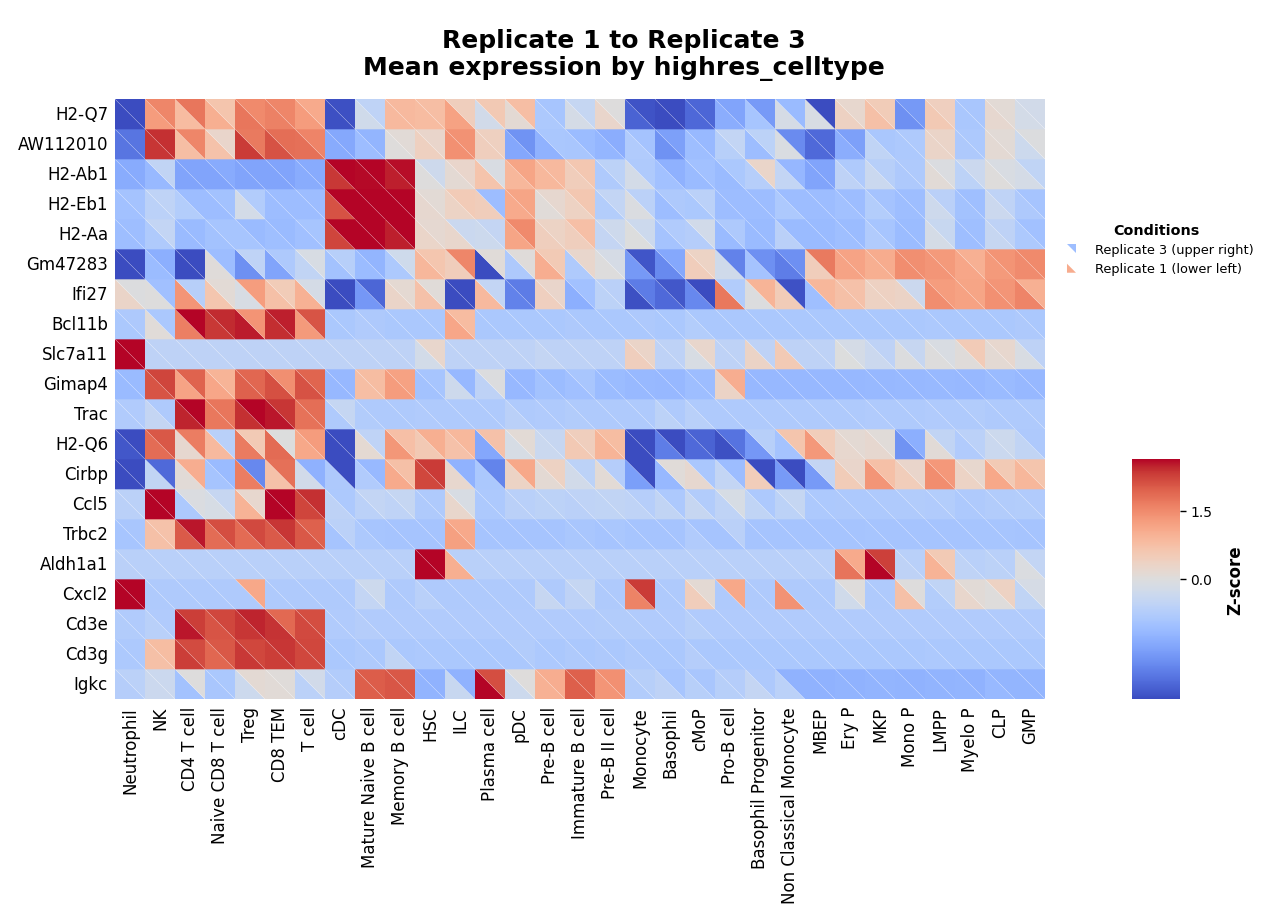

In [20]:
# Compare replicates 1 and 3
kompot.plot.heatmap(
    adata,
    genes=variable_genes,
    groupby=CELL_TYPE_COLUMN,
    condition_column=SAMPLE_COLUMN,
    condition1="1",
    condition1_name="Replicate 1",
    condition2="3",
    condition2_name="Replicate 3",
    vmin="p2",
    vmax="p98",
    cluster_rows=False,
)

These genes show substantial expression differences **between replicates of the same condition**, explaining why their significance decreases when accounting for sample variance.

## Run Tracking

Inspect metadata for both analyses:

In [21]:
# Standard analysis
run0 = kompot.RunInfo(adata, run_id=0, analysis_type="de")
run0

Parameter,Value
conditions,Young to Old
obsm_key,DM_EigenVectors
uses_sample_variance,False
layer,logged_counts
timestamp,2026-03-26T06:01:24.674200
Fields Created,9
Parameter,Value
auto_filtered,False
batch_size,100
compute_mahalanobis,True


In [22]:
# Compare runs
run0.compare_with(1)

RunComparison(run1=0, run2=1, same_fields=4, different_params=5)

## Best Practices

### When to Use Sample Variance

**Use sample variance when:**
- You have ≥3 biological replicates per condition
- You want conservative, reproducible results
- Inter-sample variability is expected (e.g., patient samples)

**Skip sample variance when:**
- Only one sample per condition
- Computational resources are limited

### Resource Considerations

Sample variance increases computation time and memory:

- **DA**: Modest increase (one estimator per sample)
- **DE**: Substantial increase (gene-specific covariances)

For DE with sample variance:
1. Always run `kompot.de(..., dry_run=True)` first
2. Consider analyzing a subset of genes (top hits from standard analysis)
3. Use `storage=StorageSettings(store_arrays_on_disk=True)` for large datasets
4. Set `fdr=FDRSettings(null_genes=0)` if you don't need FDR thresholds

### Interpretation

Results with sample variance are:
- **More conservative**: Fewer significant findings
- **More reproducible**: Robust to sample-specific effects
- **More biologically meaningful**: Account for natural variation

Genes/cell states that remain significant after sample variance correction represent robust biological signals consistent across replicates.

## Saving Results

In [23]:
# Cleanup large layers from both runs
kompot.cleanup(adata)

[2026-03-26 06:25:16,388] [INFO    ] Cleaning up all 2 run(s)
[2026-03-26 06:25:16,398] [INFO    ] Cleaned up 3 field(s) from run 0:
[2026-03-26 06:25:16,399] [INFO    ]   layers (3 field(s)):
[2026-03-26 06:25:16,400] [INFO    ]     - kompot_de_Young_imputed
[2026-03-26 06:25:16,401] [INFO    ]     - kompot_de_Old_imputed
[2026-03-26 06:25:16,401] [INFO    ]     - kompot_de_Young_to_Old_fold_change
[2026-03-26 06:25:16,413] [INFO    ] Cleaned up 2 field(s) from run 1:
[2026-03-26 06:25:16,414] [INFO    ]   layers (2 field(s)):
[2026-03-26 06:25:16,414] [INFO    ]     - kompot_de_Young_std
[2026-03-26 06:25:16,415] [INFO    ]     - kompot_de_Old_std
[2026-03-26 06:25:16,415] [INFO    ] Total: Cleaned up 5 field(s) across 2 run(s)


In [24]:
adata.write_h5ad("../data/murine_bone_marrow_aging_with_sample_variance.h5ad")

## Summary

This tutorial demonstrated:

✓ Why sample variance matters in multi-sample studies  
✓ How to enable sample variance with `sample_col` parameter  
✓ Resource planning for sample variance analyses  
✓ Comparing results with/without sample variance  
✓ Identifying sample-variable genes  
✓ Best practices for sample variance analysis  

### Key Takeaways

1. Sample variance provides **more reliable** significance estimates when you have biological replicates
2. Effect sizes remain **identical**; only statistical significance changes
3. Results are **more conservative** but also more reproducible
4. Use **resource planning** for DE with sample variance due to increased memory requirements

For more information, see the [Kompot documentation](https://kompot.readthedocs.io/en/latest/).